# Fraud Risk Scoring and LLM-Assisted Analyst Explanation System

This notebook extends a fraud classification project with threshold policy analysis, SHAP local explanations, and analyst-facing LLM notes. The Random Forest produces the fraud score; the LLM only summarizes verified model evidence.

## 1. Setup

In [1]:
# Run this once if these packages are not installed:
# pip install shap openai

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from openai import OpenAI

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, average_precision_score,
    confusion_matrix
)

DATA_PATH = Path("../data/raw/creditcard.csv")
OUTPUT_DIR = Path("../reports/llm_explanations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and profile data

Put Kaggle `creditcard.csv` under `data/raw/creditcard.csv` before running.


In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())

print("Fraud count:")
display(df["Class"].value_counts())

print("Fraud rate:")
print(df["Class"].mean())

print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Fraud count:


Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate:
0.001727485630620034
Missing values:


Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
dtype: int64

## 3. Train / validation / test split

The validation set is used for model and threshold selection. The test set remains untouched until the final evaluation and analyst-explanation stage.


In [3]:
X = df.drop(columns=["Class"])
y = df["Class"]

# 60% train / 20% validation / 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("Train:", X_train.shape, "fraud:", int(y_train.sum()))
print("Validation:", X_val.shape, "fraud:", int(y_val.sum()))
print("Test:", X_test.shape, "fraud:", int(y_test.sum()))


Train: (170883, 30) fraud: 295
Validation: (56962, 30) fraud: 99
Test: (56962, 30) fraud: 98


## 4. Train baseline models and select on validation AP

Average Precision (AP) is the primary model-selection metric because the target is highly imbalanced. Trapezoidal PR-AUC is also reported separately.


In [4]:
# Use the same model settings as the risk-scoring notebook.
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    precision_recall_curve, auc, confusion_matrix,
    accuracy_score, roc_auc_score
)

def pr_auc_trapezoid(y_true, scores):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, scores)
    return auc(recall_curve[::-1], precision_curve[::-1])

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

scaler.fit(X_train[["Time", "Amount"]])
X_train_scaled[["Time", "Amount"]] = scaler.transform(X_train[["Time", "Amount"]])
X_val_scaled[["Time", "Amount"]] = scaler.transform(X_val[["Time", "Amount"]])
X_test_scaled[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf
}

results = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        val_scores = model.predict_proba(X_val_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        val_scores = model.predict_proba(X_val)[:, 1]

    val_preds = (val_scores >= 0.5).astype(int)

    results[name] = {
        "model": model,
        "validation_scores": val_scores,
        "precision@0.5": precision_score(y_val, val_preds, zero_division=0),
        "recall@0.5": recall_score(y_val, val_preds, zero_division=0),
        "f1@0.5": f1_score(y_val, val_preds, zero_division=0),
        "average_precision": average_precision_score(y_val, val_scores),
        "pr_auc_trapezoid": pr_auc_trapezoid(y_val, val_scores)
    }

validation_model_table = pd.DataFrame(results).T[
    ["precision@0.5", "recall@0.5", "f1@0.5", "average_precision", "pr_auc_trapezoid"]
]
display(validation_model_table)

best_model_name = validation_model_table["average_precision"].idxmax()
best_validation_scores = results[best_model_name]["validation_scores"]

print("Selected model from validation AP:", best_model_name)


,precision@0.5,recall@0.5,f1@0.5,average_precision,pr_auc_trapezoid
Logistic Regression,0.059058,0.89899,0.110834,0.683091,0.716492
Random Forest,0.835165,0.767677,0.8,0.747687,0.746676


Selected model from validation AP: Random Forest


## 5. Select the review threshold on validation data

Threshold tuning is performed only on the validation set. The simple cost assumption is:

- each false-positive investigation costs `$5`;
- each missed fraud costs its transaction amount.

The test set is not used to choose the threshold.


In [5]:
def threshold_policy_table(
    y_true,
    scores,
    thresholds,
    amount_series=None,
    false_positive_investigation_cost=5
):
    rows = []
    y_true = np.array(y_true)
    scores = np.array(scores)

    if amount_series is None:
        amount_series = np.zeros(len(y_true))
    amount_series = np.array(amount_series)

    for t in thresholds:
        pred = (scores >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

        review_count = int(pred.sum())
        missed_fraud_amount = float(
            amount_series[(y_true == 1) & (pred == 0)].sum()
        )
        fp_cost = int(fp) * false_positive_investigation_cost
        total_estimated_cost = fp_cost + missed_fraud_amount

        rows.append({
            "split": "validation",
            "threshold": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "true_positives": int(tp),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "review_workload": review_count,
            "review_rate": review_count / len(y_true),
            "false_positive_investigation_cost": fp_cost,
            "missed_fraud_amount": missed_fraud_amount,
            "total_estimated_cost": total_estimated_cost
        })

    return pd.DataFrame(rows)

thresholds = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]

policy = threshold_policy_table(
    y_val,
    best_validation_scores,
    thresholds,
    amount_series=X_val["Amount"] if "Amount" in X_val.columns else None
)

selected_threshold = float(
    policy.loc[policy["total_estimated_cost"].idxmin(), "threshold"]
)

display(policy)
print("Validation-selected threshold:", selected_threshold)

policy.to_csv(OUTPUT_DIR / "threshold_policy_table.csv", index=False)


,split,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,review_workload,review_rate,false_positive_investigation_cost,missed_fraud_amount,total_estimated_cost
0,validation,0.05,0.023325,0.949495,0.045532,94,3936,5,4030,0.070749,19680,1077.85,20757.85
1,validation,0.10,0.070261,0.868687,0.130008,86,1138,13,1224,0.021488,5690,2409.44,8099.44
2,validation,0.20,0.270903,0.818182,0.407035,81,218,18,299,0.005249,1090,3139.32,4229.32
3,validation,0.30,0.533333,0.808081,0.642570,80,70,19,150,0.002633,350,3140.32,3490.32
4,validation,0.50,0.835165,0.767677,0.800000,76,15,23,91,0.001598,75,3143.32,3218.32
5,validation,0.70,0.884615,0.696970,0.779661,69,9,30,78,0.001369,45,3483.82,3528.82
6,validation,0.90,0.861538,0.565657,0.682927,56,9,43,65,0.001141,45,5881.22,5926.22


Validation-selected threshold: 0.5


## 6. Plot validation threshold tradeoffs


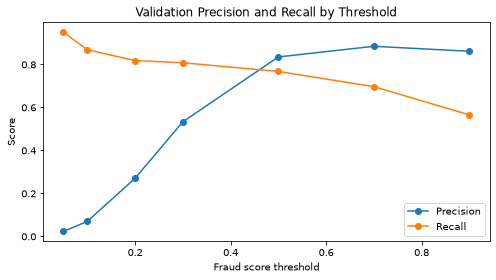

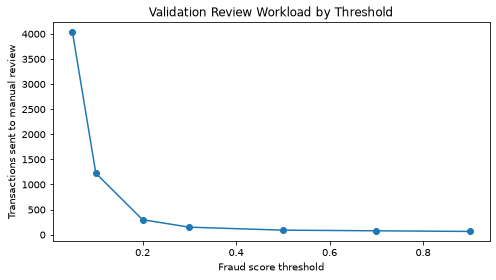

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(policy["threshold"], policy["precision"], marker="o", label="Precision")
plt.plot(policy["threshold"], policy["recall"], marker="o", label="Recall")
plt.xlabel("Fraud score threshold")
plt.ylabel("Score")
plt.title("Validation Precision and Recall by Threshold")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "precision_recall_by_threshold.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(policy["threshold"], policy["review_workload"], marker="o")
plt.xlabel("Fraud score threshold")
plt.ylabel("Transactions sent to manual review")
plt.title("Validation Review Workload by Threshold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "review_workload_by_threshold.png", dpi=200)
plt.show()


## 7. Final test evaluation and select transactions for analyst explanation

The model and threshold have already been chosen from validation data. This section evaluates them on the untouched test set, then selects the highest-risk test records sent to review.


In [7]:
# Score the untouched test set once model and threshold choices are fixed.
if best_model_name == "Random Forest":
    final_test_scores = results["Random Forest"]["model"].predict_proba(X_test)[:, 1]
else:
    final_test_scores = results["Logistic Regression"]["model"].predict_proba(X_test_scaled)[:, 1]

final_test_preds = (final_test_scores >= selected_threshold).astype(int)

final_test_metrics = pd.DataFrame({
    "model": [best_model_name],
    "selected_threshold_from_validation": [selected_threshold],
    "precision": [precision_score(y_test, final_test_preds, zero_division=0)],
    "recall": [recall_score(y_test, final_test_preds, zero_division=0)],
    "f1": [f1_score(y_test, final_test_preds, zero_division=0)],
    "average_precision": [average_precision_score(y_test, final_test_scores)],
    "pr_auc_trapezoid": [pr_auc_trapezoid(y_test, final_test_scores)],
    "accuracy_reference": [accuracy_score(y_test, final_test_preds)],
    "roc_auc_reference": [roc_auc_score(y_test, final_test_scores)]
})

display(final_test_metrics)
final_test_metrics.to_csv(OUTPUT_DIR / "final_test_metrics.csv", index=False)

test_output = X_test.copy()
test_output["true_label"] = y_test.values
test_output["fraud_score"] = final_test_scores
test_output["decision"] = np.where(
    test_output["fraud_score"] >= selected_threshold,
    "Review",
    "Pass"
)

# This is the original dataframe row index, not a real card-network transaction ID.
test_output["record_id"] = test_output.index

review_count = int((test_output["decision"] == "Review").sum())
print("Test records sent to review:", review_count)

flagged = (
    test_output[test_output["decision"] == "Review"]
    .sort_values("fraud_score", ascending=False)
    .head(50)
    .reset_index(drop=True)
)

display(flagged[["record_id", "Amount", "fraud_score", "decision", "true_label"]].head())
flagged.to_csv(OUTPUT_DIR / "flagged_transactions.csv", index=False)


,model,selected_threshold_from_validation,precision,recall,f1,average_precision,pr_auc_trapezoid,accuracy_reference,roc_auc_reference
0,Random Forest,0.5,0.82,0.836735,0.828283,0.793414,0.794728,0.999403,0.977921


Test records sent to review: 100


,record_id,Amount,fraud_score,decision,true_label
0,42009,112.33,0.999531,Review,1
1,44556,1.00,0.999520,Review,1
2,119781,124.53,0.999518,Review,1
3,143728,1.00,0.999517,Review,1
4,150665,209.65,0.999514,Review,1


## 8. Build local risk signals with SHAP

SHAP is applied to the selected high-risk **test records**. It identifies which model features pushed each fraud score upward.

Because `V1` to `V28` are anonymized, these features are reported only as model signals. No merchant, identity, device, location, or other real-world meaning is inferred.


In [8]:
if best_model_name != "Random Forest":
    raise ValueError(
        "This SHAP section is written for the Random Forest model. "
        "Update the explainer if a different model is selected."
    )

rf_model = results["Random Forest"]["model"]
model_columns = list(X_train.columns)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(flagged[model_columns])

# SHAP versions return classification results in two common formats.
if isinstance(shap_values, list):
    fraud_shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    fraud_shap_values = shap_values[:, :, 1]
else:
    fraud_shap_values = shap_values

local_signals = []
signal_features = []

for i in range(len(flagged)):
    contributions = pd.Series(fraud_shap_values[i], index=model_columns)
    positive_contributions = contributions[contributions > 0]
    top_three = positive_contributions.sort_values(ascending=False).head(3)

    feature_names = list(top_three.index)
    signal_features.append(", ".join(feature_names))

    signal_text = []
    for feature in feature_names:
        feature_value = flagged.loc[i, feature]
        shap_value = top_three[feature]
        signal_text.append(
            f"{feature}={feature_value:.3f} (SHAP contribution +{shap_value:.3f})"
        )

    local_signals.append("; ".join(signal_text))

flagged["signal_features"] = signal_features
flagged["local_signals"] = local_signals

explanation_input = flagged[[
    "record_id", "Amount", "fraud_score", "decision",
    "signal_features", "local_signals"
]].copy()
explanation_input["threshold"] = selected_threshold

display(explanation_input.head())
explanation_input.to_csv(
    OUTPUT_DIR / "flagged_transaction_explanations_input.csv",
    index=False
)


,record_id,Amount,fraud_score,decision,signal_features,local_signals,threshold
0,42009,112.33,0.999531,Review,"V14, V12, V17",V14=-8.226 (SHAP contribution +0.126); V12=-7....,0.5
1,44556,1.00,0.999520,Review,"V14, V10, V17",V14=-7.246 (SHAP contribution +0.129); V10=-5....,0.5
2,119781,124.53,0.999518,Review,"V14, V10, V12",V14=-7.495 (SHAP contribution +0.133); V10=-5....,0.5
3,143728,1.00,0.999517,Review,"V14, V10, V12",V14=-8.604 (SHAP contribution +0.130); V10=-6....,0.5
4,150665,209.65,0.999514,Review,"V14, V10, V12",V14=-11.030 (SHAP contribution +0.130); V10=-1...,0.5


## 9. Generate analyst-facing explanations with an LLM

The fraud model makes the scoring and review decision. The LLM does **not** predict fraud; it only converts verified model evidence into a short analyst-facing note.

The example generates explanations for the first 10 of the up-to-50 highest-risk test records selected above, which limits API cost. Store the OpenAI API key in the `OPENAI_API_KEY` environment variable before running.


### OpenAI API setup

Enter your own OpenAI API key when prompted.
The key is hidden while typing and is not saved in the notebook output.

Do not commit a real API key to a public repository.

In [15]:
from getpass import getpass
from openai import OpenAI

OPENAI_API_KEY = "Enter your OpenAI API key: "

client = OpenAI(api_key=OPENAI_API_KEY)

In [11]:
def generate_explanation(row):
    prompt = f"""
Write a short explanation for a fraud analyst. Use only the facts below.
Do not invent a merchant, cardholder, device, IP address, identity, or location.
Do not claim that an anonymized feature has a real-world meaning.
Mention that the record needs manual review, give the score and threshold,
and name the three local model signals. Copy the numbers exactly as shown.
Write 2 or 3 simple sentences.

Record ID: {row['record_id']}
Fraud score: {row['fraud_score']:.3f}
Review threshold: {row['threshold']:.2f}
Transaction amount: {row['Amount']:.2f}
Local model signals: {row['local_signals']}
"""

    response = client.responses.create(
        model="gpt-5-mini",
        input=prompt,
        store=False
    )
    return response.output_text.strip()

explanations = explanation_input.head(10).copy()
llm_outputs = []

for i in range(len(explanations)):
    explanation = generate_explanation(explanations.iloc[i])
    llm_outputs.append(explanation)

explanations["analyst_explanation"] = llm_outputs

display(
    explanations[
        ["record_id", "fraud_score", "decision", "analyst_explanation"]
    ]
)
explanations.to_csv(OUTPUT_DIR / "analyst_explanations.csv", index=False)


,record_id,fraud_score,decision,analyst_explanation
0,42009,0.999531,Review,Record ID 42009 needs manual review. Fraud sco...
1,44556,0.999520,Review,Record ID: 44556 needs manual review; fraud sc...
2,119781,0.999518,Review,Record ID 119781 requires manual review becaus...
3,143728,0.999517,Review,Record 143728 needs manual review; fraud score...
4,150665,0.999514,Review,Record ID 150665 needs manual review: fraud sc...
5,150647,0.999512,Review,Record 150647 (transaction amount 8.54) needs ...
6,42769,0.999510,Review,Record ID 42769 with transaction amount 118.30...
7,150663,0.999510,Review,"Record ID: 150663 has a fraud score of 1.000, ..."
8,42756,0.999507,Review,Record ID: 42756 needs manual review. \nFraud...
9,42696,0.999507,Review,Record ID: 42696 needs manual review; Fraud sc...


## 10. Simple faithfulness checks

These checks do not prove that an explanation is perfect. They catch three basic failures: a missing score or threshold, missing local feature names, and unsupported real-world claims. Flagged explanations should still be read manually.

In [12]:
unsupported_terms = [
    "merchant", "cardholder", "device", "ip address",
    "identity", "location", "country", "city"
]

check_rows = []

for i in range(len(explanations)):
    row = explanations.iloc[i]
    text = row["analyst_explanation"].lower()

    score_is_present = f"{row['fraud_score']:.3f}" in text
    threshold_is_present = f"{row['threshold']:.2f}" in text

    feature_names = row["signal_features"].split(", ")
    features_are_present = all(
        feature.lower() in text for feature in feature_names
    )

    found_unsupported_term = any(
        term in text for term in unsupported_terms
    )

    passed = (
        score_is_present
        and threshold_is_present
        and features_are_present
        and not found_unsupported_term
    )

    check_rows.append({
        "record_id": row["record_id"],
        "score_present": score_is_present,
        "threshold_present": threshold_is_present,
        "local_features_present": features_are_present,
        "unsupported_claim_flag": found_unsupported_term,
        "passed_basic_checks": passed,
        "analyst_explanation": row["analyst_explanation"]
    })

eval_table = pd.DataFrame(check_rows)
display(eval_table)

eval_table.to_csv(
    OUTPUT_DIR / "llm_explanation_faithfulness_review.csv",
    index=False
)

print(
    "Passed basic checks:",
    int(eval_table["passed_basic_checks"].sum()),
    "out of",
    len(eval_table)
)


,record_id,score_present,threshold_present,local_features_present,unsupported_claim_flag,passed_basic_checks,analyst_explanation
0,42009,True,True,True,False,True,Record ID 42009 needs manual review. Fraud sco...
1,44556,True,True,True,False,True,Record ID: 44556 needs manual review; fraud sc...
2,119781,True,True,True,False,True,Record ID 119781 requires manual review becaus...
3,143728,True,True,True,False,True,Record 143728 needs manual review; fraud score...
4,150665,True,True,True,False,True,Record ID 150665 needs manual review: fraud sc...
5,150647,True,True,True,False,True,Record 150647 (transaction amount 8.54) needs ...
6,42769,True,True,True,False,True,Record ID 42769 with transaction amount 118.30...
7,150663,True,True,True,False,True,"Record ID: 150663 has a fraud score of 1.000, ..."
8,42756,True,True,True,False,True,Record ID: 42756 needs manual review. \nFraud...
9,42696,True,True,True,False,True,Record ID: 42696 needs manual review; Fraud sc...


Passed basic checks: 10 out of 10


## 11. Short project summary for README or interview

This summary reports the final untouched-test performance after model and threshold selection were completed on validation data.


In [13]:
test_row = final_test_metrics.iloc[0]

summary_text = f'''
Project summary:
I built a fraud classification and risk-scoring pipeline for a highly imbalanced dataset.
I trained Logistic Regression and Random Forest on a training split, selected the model using validation Average Precision (AP), and selected the review threshold using a simple validation-set cost analysis.
I then evaluated the fixed model and threshold on an untouched test set.
For the highest-risk test records sent to review, I used SHAP to identify local model signals that increased each fraud score.
I sent only the verified score, threshold, amount, and SHAP signals to an LLM to create short analyst notes.
Finally, I ran simple rule-based checks for missing evidence and unsupported real-world claims.

Selected model: {best_model_name}
Validation-selected threshold: {selected_threshold:.2f}
Final test Average Precision (AP): {test_row['average_precision']:.3f}
Final test PR-AUC (trapezoidal): {test_row['pr_auc_trapezoid']:.3f}
Final test precision at selected threshold: {test_row['precision']:.3f}
Final test recall at selected threshold: {test_row['recall']:.3f}
Test records sent to review: {review_count}
High-risk test records prepared for SHAP explanation: {len(flagged)}
LLM explanations generated: {len(explanations)}
Explanations passing basic checks: {int(eval_table['passed_basic_checks'].sum())} out of {len(eval_table)}
'''

print(summary_text)
Path(OUTPUT_DIR / "project_summary.txt").write_text(summary_text)



Project summary:
I built a fraud classification and risk-scoring pipeline for a highly imbalanced dataset.
I trained Logistic Regression and Random Forest on a training split, selected the model using validation Average Precision (AP), and selected the review threshold using a simple validation-set cost analysis.
I then evaluated the fixed model and threshold on an untouched test set.
For the highest-risk test records sent to review, I used SHAP to identify local model signals that increased each fraud score.
I sent only the verified score, threshold, amount, and SHAP signals to an LLM to create short analyst notes.
Finally, I ran simple rule-based checks for missing evidence and unsupported real-world claims.

Selected model: Random Forest
Validation-selected threshold: 0.50
Final test Average Precision (AP): 0.793
Final test PR-AUC (trapezoidal): 0.795
Final test precision at selected threshold: 0.820
Final test recall at selected threshold: 0.837
Test records sent to review: 100
Hi

1134